In [4]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [5]:
def create_spectrogram(file_path, save_path):
    y, sr = librosa.load(file_path, sr=None)
    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    plt.figure(figsize=(3, 3))
    librosa.display.specshow(S_db, sr=sr,x_axis=None,y_axis=None, cmap='magma')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

In [6]:
def spectrograms(base_dir="C:/Users/Aashi Malay/OneDrive/Desktop/lyrengist", output_dir="C:/Users/Aashi Malay/OneDrive/Desktop/lyrengist/spectograms"):
    os.makedirs(output_dir, exist_ok=True)
    for label in os.listdir(base_dir):
        label_path = os.path.join(base_dir, label)
        if not os.path.isdir(label_path):
            continue
        save_class_dir = os.path.join(output_dir, label)
        os.makedirs(save_class_dir, exist_ok=True)

        for i, file in enumerate(os.listdir(label_path)):
            if file.endswith('.wav'):
                file_path = os.path.join(label_path, file)
                save_path = os.path.join(save_class_dir, f"{label}_{i}.png")
                create_spectrogram(file_path, save_path)

spectrograms()


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np


In [11]:
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(
    root="C:/Users/Aashi Malay/OneDrive/Desktop/lyrengist/spectograms",
    transform=transform
)
print(train_data.class_to_idx)


{'lyrengistU': 0, 'lyrengist_healthy': 1}


In [12]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [13]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 25 * 25, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(50):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")


Epoch 1, Loss: 19.8447
Epoch 2, Loss: 18.8956
Epoch 3, Loss: 17.0343
Epoch 4, Loss: 16.6970
Epoch 5, Loss: 15.0857
Epoch 6, Loss: 14.3561
Epoch 7, Loss: 14.3196
Epoch 8, Loss: 13.7092
Epoch 9, Loss: 12.2561
Epoch 10, Loss: 11.1840
Epoch 11, Loss: 10.6885
Epoch 12, Loss: 9.8317
Epoch 13, Loss: 10.5698
Epoch 14, Loss: 8.1249
Epoch 15, Loss: 7.8191
Epoch 16, Loss: 7.3947
Epoch 17, Loss: 7.1549
Epoch 18, Loss: 6.0488
Epoch 19, Loss: 4.7345
Epoch 20, Loss: 4.7283
Epoch 21, Loss: 6.2762
Epoch 22, Loss: 5.4326
Epoch 23, Loss: 3.6290
Epoch 24, Loss: 3.1603
Epoch 25, Loss: 3.1508
Epoch 26, Loss: 2.8105
Epoch 27, Loss: 2.4343
Epoch 28, Loss: 1.9331
Epoch 29, Loss: 1.5783
Epoch 30, Loss: 1.7664
Epoch 31, Loss: 1.5780
Epoch 32, Loss: 1.7054
Epoch 33, Loss: 2.5819
Epoch 34, Loss: 1.3296
Epoch 35, Loss: 1.2876
Epoch 36, Loss: 0.8917
Epoch 37, Loss: 0.4772
Epoch 38, Loss: 0.6111
Epoch 39, Loss: 0.5499
Epoch 40, Loss: 0.5302
Epoch 41, Loss: 1.1249
Epoch 42, Loss: 0.7373
Epoch 43, Loss: 0.7728
Epoch 44

Accuracy: 83.93%


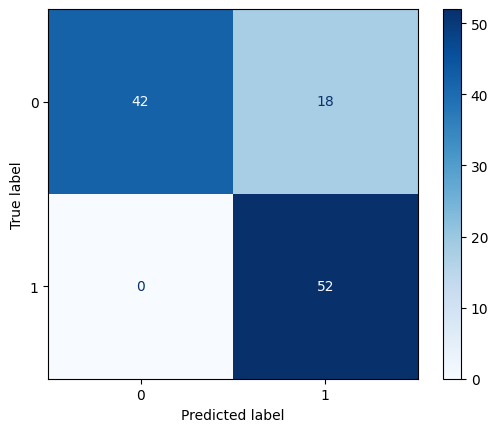

                   precision    recall  f1-score   support

       lyrengistU       1.00      0.70      0.82        60
lyrengist_healthy       0.74      1.00      0.85        52

         accuracy                           0.84       112
        macro avg       0.87      0.85      0.84       112
     weighted avg       0.88      0.84      0.84       112



In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        predicted = (outputs.cpu().numpy() > 0.5).astype(int)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted)

y_true = np.array(y_true).astype(int)
y_pred = np.array(y_pred).flatten()

accuracy = np.mean(y_true == y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = "Blues")
plt.show()
# 0-lyrengist and 1 - healthy

print(classification_report(y_true, y_pred, target_names=train_data.classes))
